In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
DATA_PATH = Path("../data/raw/customer_support_tickets.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 28,587
Columns: 16


In [4]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [8]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
for column in df.columns:
    print("-", column)

Dataset shape:
(28587, 16)

Column names:
- subject
- body
- answer
- type
- queue
- priority
- language
- version
- tag_1
- tag_2
- tag_3
- tag_4
- tag_5
- tag_6
- tag_7
- tag_8


In [9]:
pd.set_option("display.max_columns", None)

df.head(5)

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28587 entries, 0 to 28586
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   24749 non-null  str  
 1   body      28587 non-null  str  
 2   answer    28580 non-null  str  
 3   type      28587 non-null  str  
 4   queue     28587 non-null  str  
 5   priority  28587 non-null  str  
 6   language  28587 non-null  str  
 7   version   28587 non-null  int64
 8   tag_1     28587 non-null  str  
 9   tag_2     28574 non-null  str  
 10  tag_3     28451 non-null  str  
 11  tag_4     25529 non-null  str  
 12  tag_5     14545 non-null  str  
 13  tag_6     5874 non-null   str  
 14  tag_7     2040 non-null   str  
 15  tag_8     565 non-null    str  
dtypes: int64(1), str(15)
memory usage: 3.5 MB


In [11]:
df.dtypes

subject       str
body          str
answer        str
type          str
queue         str
priority      str
language      str
version     int64
tag_1         str
tag_2         str
tag_3         str
tag_4         str
tag_5         str
tag_6         str
tag_7         str
tag_8         str
dtype: object

In [12]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
tag_8,28022,98.023577
tag_7,26547,92.863889
tag_6,22713,79.452199
tag_5,14042,49.120229
subject,3838,13.425683
tag_4,3058,10.697170
tag_3,136,0.475741
tag_2,13,0.045475
answer,7,0.024487
language,0,0.000000


In [15]:
duplicate_rows = df.duplicated().sum()
print(f"Duplicate complete rows: {duplicate_rows:,}")

Duplicate complete rows: 0


In [16]:
df["combined_text"] = (
    df["subject"].fillna("").astype(str)
    + " "
    + df["body"].fillna("").astype(str)
).str.strip()

duplicate_text = df["combined_text"].duplicated().sum()

print(f"Duplicate ticket texts: {duplicate_text:,}")

Duplicate ticket texts: 0


In [18]:
language_counts = df["language"].value_counts()
language_counts

language_percent = (
    df["language"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

language_percent

language
en    57.15
de    42.85
Name: proportion, dtype: float64

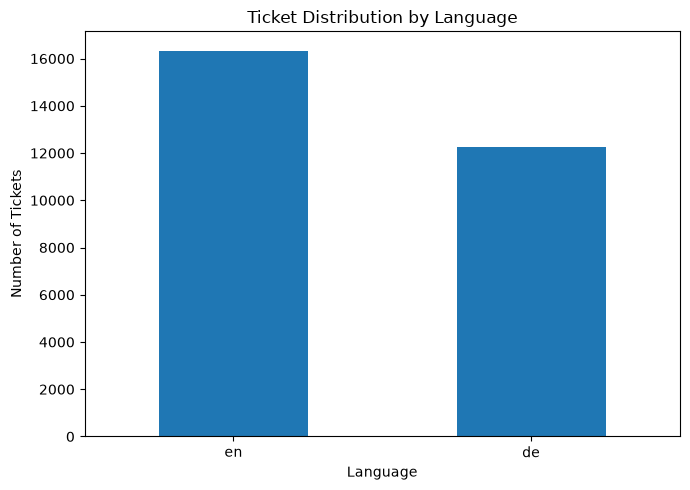

In [19]:
plt.figure(figsize=(7, 5))

language_counts.plot(kind="bar")

plt.title("Ticket Distribution by Language")
plt.xlabel("Language")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [22]:
#Queue
number_of_queues = df["queue"].nunique()
print(f"Number of unique queues: {number_of_queues}")

queue_counts = df["queue"].value_counts()
queue_counts

Number of unique queues: 10


queue
Technical Support                  8362
Product Support                    5252
Customer Service                   4268
IT Support                         3433
Billing and Payments               2788
Returns and Exchanges              1437
Service Outages and Maintenance    1148
Sales and Pre-Sales                 918
Human Resources                     576
General Inquiry                     405
Name: count, dtype: int64

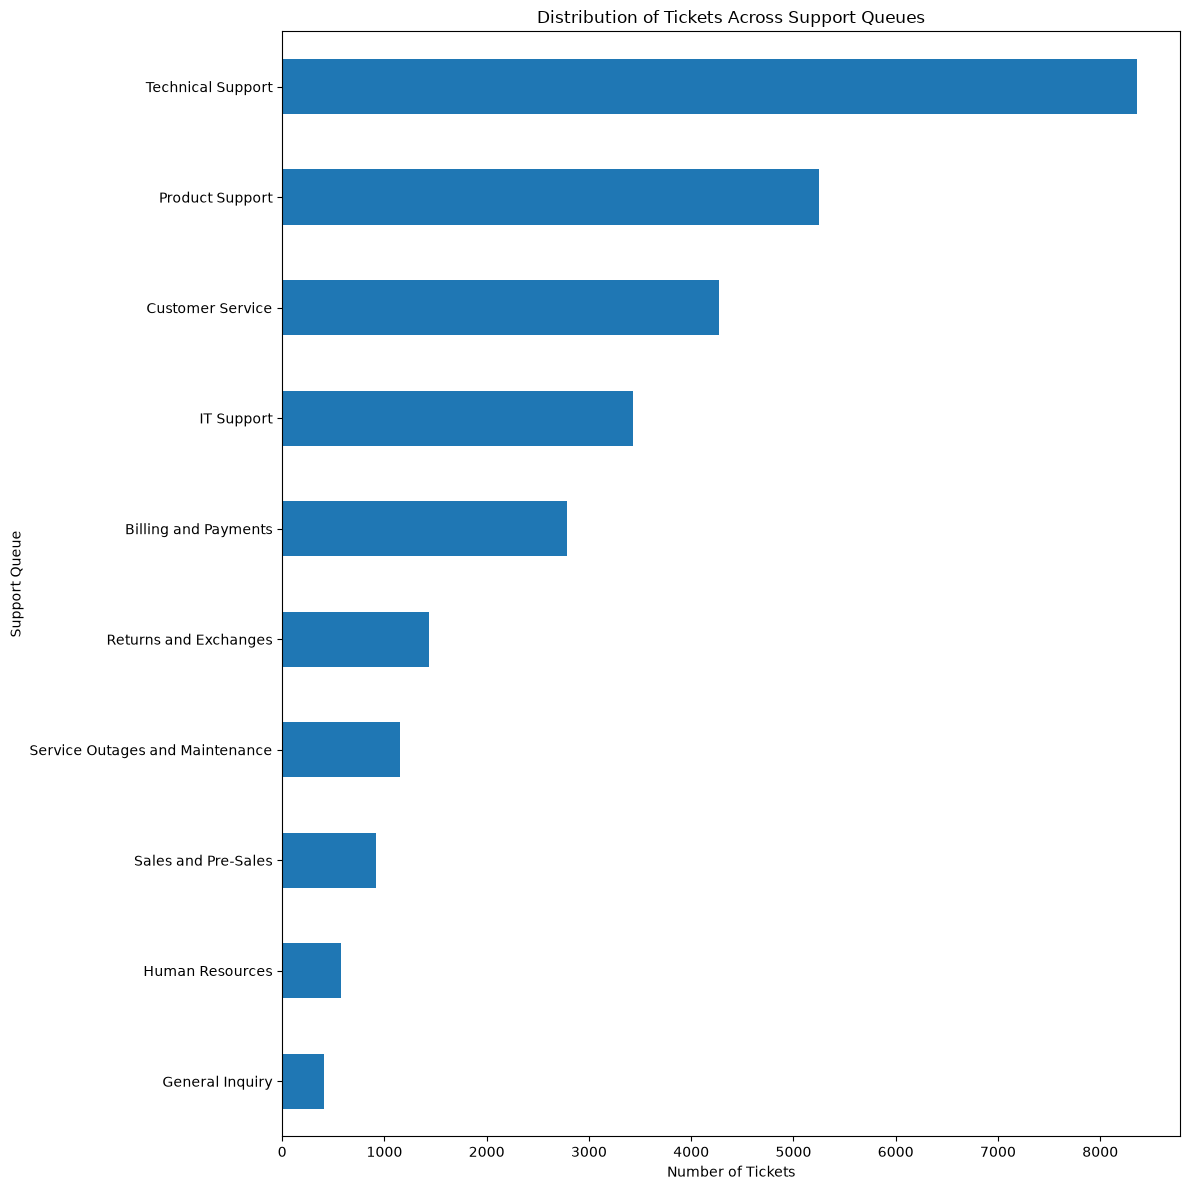

In [23]:
plt.figure(figsize=(12, 12))

queue_counts.sort_values().plot(kind="barh")

plt.title("Distribution of Tickets Across Support Queues")
plt.xlabel("Number of Tickets")
plt.ylabel("Support Queue")

plt.tight_layout()
plt.show()

In [24]:
queue_statistics = pd.DataFrame({
    "ticket_count": queue_counts,
    "percentage": (
        queue_counts / len(df) * 100
    ).round(2)
})

queue_statistics

,ticket_count,percentage
queue,,
Technical Support,8362,29.25
Product Support,5252,18.37
Customer Service,4268,14.93
IT Support,3433,12.01
Billing and Payments,2788,9.75
Returns and Exchanges,1437,5.03
Service Outages and Maintenance,1148,4.02
Sales and Pre-Sales,918,3.21
Human Resources,576,2.01


In [28]:
#Priority analysis
priority_counts = df["priority"].value_counts()
priority_counts



priority
medium    11515
high      11178
low        5894
Name: count, dtype: int64

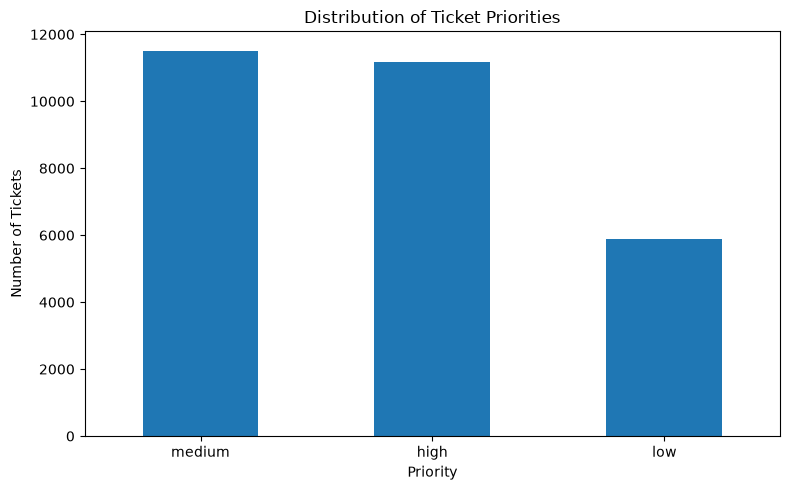

In [29]:
plt.figure(figsize=(8, 5))

priority_counts.plot(kind="bar")

plt.title("Distribution of Ticket Priorities")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [31]:
#Ticket type analysis
type_counts = df["type"].value_counts()
type_counts



type
Incident    11466
Request      8187
Problem      6012
Change       2922
Name: count, dtype: int64

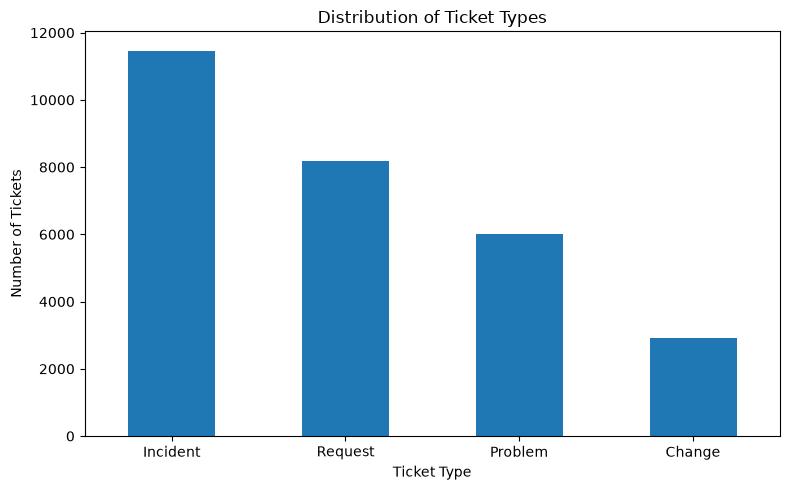

In [32]:
plt.figure(figsize=(8, 5))

type_counts.plot(kind="bar")

plt.title("Distribution of Ticket Types")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
#Subject and body analysis
df["subject_length"] = (
    df["subject"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["body_length"] = (
    df["body"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["text_length"] = (
    df["combined_text"]
    .str.len()
)

text_statistics = df[
    ["subject_length", "body_length", "text_length"]
].describe()

text_statistics

,subject_length,body_length,text_length
count,28587.000000,28587.000000,28587.000000
mean,38.546122,387.263896,426.673768
std,23.672887,200.129011,200.835093
min,0.000000,6.000000,13.000000
25%,27.000000,219.000000,261.000000
50%,39.000000,386.000000,426.000000
75%,51.000000,551.000000,587.000000
max,675.000000,1469.000000,1526.000000


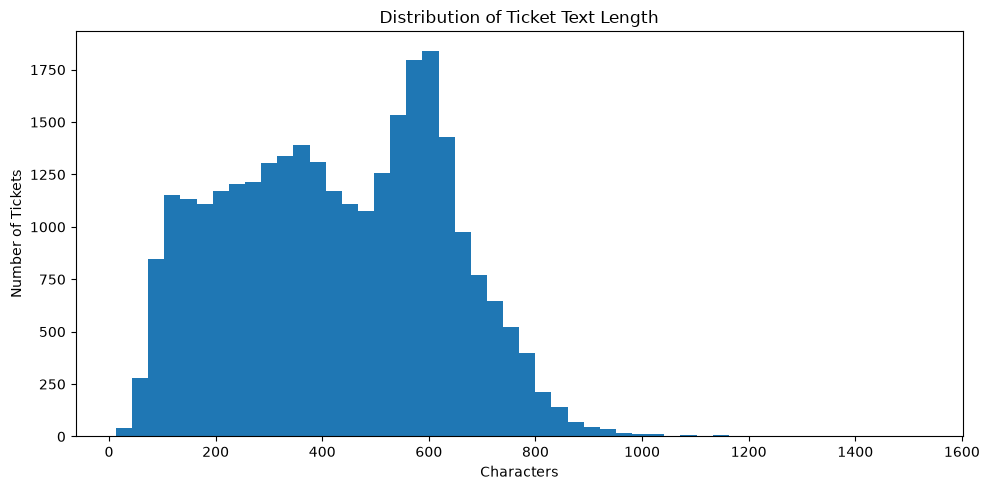

In [36]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["text_length"],
    bins=50
)

plt.title("Distribution of Ticket Text Length")
plt.xlabel("Characters")
plt.ylabel("Number of Tickets")

plt.tight_layout()
plt.show()

In [37]:
#Check empty subjects/bodies
empty_subjects = (
    df["subject"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

empty_bodies = (
    df["body"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print(f"Empty subjects: {empty_subjects:,}")
print(f"Empty bodies: {empty_bodies:,}")

Empty subjects: 3,838
Empty bodies: 0


In [ ]:
#Define our initial ML columns
MODEL_INPUT_COLUMNS = [
    "subject",
    "body"
]

TARGET_COLUMN = "queue"

SECONDARY_TARGET = "priority"

EXCLUDED_COLUMNS = [
    "answer",
    "tag_1",
    "tag_2",
    "tag_3",
    "tag_4",
    "tag_5",
    "tag_6",
    "tag_7",
    "tag_8"
]

print("Model inputs:", MODEL_INPUT_COLUMNS)
print("Primary target:", TARGET_COLUMN)
print("Secondary target:", SECONDARY_TARGET)
print("Excluded fields:", EXCLUDED_COLUMNS)

In [38]:
#check target validity
print("Missing queue labels:", df["queue"].isna().sum())
print("Unique queue labels:", df["queue"].nunique())

print("Missing queue labels:", df["queue"].isna().sum())
print("Unique queue labels:", df["queue"].nunique())

Missing queue labels: 0
Unique queue labels: 10
Missing queue labels: 0
Unique queue labels: 10
